In [ ]:
# CELL 0 — Upload an image from your desktop and set image_name

from google.colab import files

uploaded = files.upload()  # opens file picker

# Grab the first uploaded file name
image_name = list(uploaded.keys())[0]

print(f"Image uploaded and ready: {image_name}")

Saving chairs.png to chairs.png
Image uploaded and ready: chairs.png


In [ ]:
# CELL 1 — Install + Imports
!pip install -q transformers accelerate opencv-python pillow

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

import torch
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

print("Environment ready.")

Environment ready.


In [ ]:
# CELL 2 — Load Mask2Former Swin-B COCO Panoptic

model_id = "facebook/mask2former-swin-base-coco-panoptic"

processor = AutoImageProcessor.from_pretrained(model_id)
model = Mask2FormerForUniversalSegmentation.from_pretrained(model_id).to("cuda")

print("Mask2Former Swin-B COCO Panoptic loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

The image processor of type `Mask2FormerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/9.12k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/432M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2Former Swin-B COCO Panoptic loaded.


In [ ]:
# CELL 3 — Count person (0), purse (26), backpack (24), chair (56), laptop (63), book (73)

def count_objects_in_image(image_path):
    # Load image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)

    # Prepare inputs
    inputs = processor(images=pil_img, return_tensors="pt").to("cuda")

    # Run model
    with torch.no_grad():
        outputs = model(**inputs)

    # Panoptic post-processing
    result = processor.post_process_panoptic_segmentation(
        outputs,
        target_sizes=[pil_img.size[::-1]]
    )[0]

    segments_info = result["segments_info"]

    # COCO class IDs
    PERSON = 0
    BACKPACK = 24
    PURSE = 26
    CHAIR = 56
    LAPTOP = 63
    BOOK = 73

    # Count each category
    person_count   = sum(1 for seg in segments_info if seg["label_id"] == PERSON)
    purse_count    = sum(1 for seg in segments_info if seg["label_id"] == PURSE)
    backpack_count = sum(1 for seg in segments_info if seg["label_id"] == BACKPACK)
    chair_count    = sum(1 for seg in segments_info if seg["label_id"] == CHAIR)
    laptop_count   = sum(1 for seg in segments_info if seg["label_id"] == LAPTOP)
    book_count     = sum(1 for seg in segments_info if seg["label_id"] == BOOK)

    return (
        person_count,
        purse_count,
        backpack_count,
        chair_count,
        laptop_count,
        book_count,
        img_rgb,
        result["segmentation"]
    )


# Run the combined counter
persons, purses, backpacks, chairs, laptops, books, img_rgb, seg_map = count_objects_in_image(image_name)

print("=== OBJECT COUNTS ===")
print(f"People detected:    {persons}")
print(f"Purses detected:    {purses}")
print(f"Backpacks detected: {backpacks}")
print(f"Chairs detected:    {chairs}")
print(f"Laptops detected:   {laptops}")
print(f"Books detected:     {books}")

`label_ids_to_fuse` unset. No instance will be fused.


=== OBJECT COUNTS ===
People detected:    0
Purses detected:    0
Backpacks detected: 0
Chairs detected:    21
Laptops detected:   0
Books detected:     0


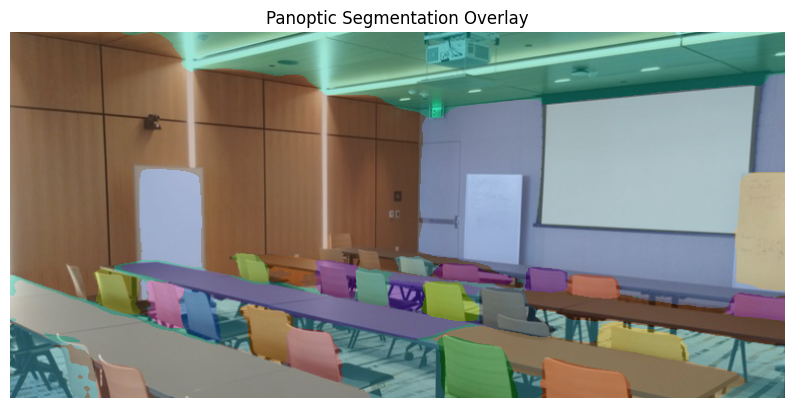

In [ ]:
# CELL 4 — Visualize segmentation overlay (optional)

def visualize_segmentation(image_rgb, seg_map):
    seg = seg_map.cpu().numpy()
    colored = np.zeros_like(image_rgb)

    # Random colors for each instance
    unique_ids = np.unique(seg)
    rng = np.random.default_rng(42)

    colors = {uid: rng.integers(0, 255, size=3) for uid in unique_ids}

    for uid in unique_ids:
        colored[seg == uid] = colors[uid]

    blended = (0.6 * image_rgb + 0.4 * colored).astype(np.uint8)

    plt.figure(figsize=(10, 10))
    plt.imshow(blended)
    plt.axis("off")
    plt.title("Panoptic Segmentation Overlay")
    plt.show()

visualize_segmentation(img_rgb, seg_map)

In [ ]:
# CELL 5 — Display segments_info (instance ID, class ID, confidence)

def display_segments_info(image_path):
    # Load image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)

    # Prepare inputs
    inputs = processor(images=pil_img, return_tensors="pt").to("cuda")

    # Run model
    with torch.no_grad():
        outputs = model(**inputs)

    # Panoptic post-processing
    result = processor.post_process_panoptic_segmentation(
        outputs,
        target_sizes=[pil_img.size[::-1]]
    )[0]

    segments_info = result["segments_info"]

    # Print the list in your preferred format
    print("\n=== SEGMENTS INFO (All Detected Instances) ===")
    for seg in segments_info:
        print(f"ID: {seg['id']:>4} | Class: {seg['label_id']:>2} | Score: {seg.get('score', 1.0):.3f}")


# Run the display
display_segments_info(image_name)

`label_ids_to_fuse` unset. No instance will be fused.



=== SEGMENTS INFO (All Detected Instances) ===
ID:    1 | Class: 60 | Score: 0.957
ID:    2 | Class: 56 | Score: 0.985
ID:    3 | Class: 56 | Score: 0.928
ID:    4 | Class: 60 | Score: 0.936
ID:    5 | Class: 56 | Score: 0.942
ID:    6 | Class: 56 | Score: 0.982
ID:    7 | Class: 56 | Score: 0.610
ID:    8 | Class: 60 | Score: 0.842
ID:    9 | Class: 56 | Score: 0.935
ID:   10 | Class: 60 | Score: 0.936
ID:   11 | Class: 56 | Score: 0.961
ID:   12 | Class: 56 | Score: 0.955
ID:   13 | Class: 56 | Score: 0.780
ID:   14 | Class: 56 | Score: 0.504
ID:   15 | Class: 56 | Score: 0.684
ID:   16 | Class: 62 | Score: 0.866
ID:   17 | Class: 56 | Score: 0.978
ID:   18 | Class: 56 | Score: 0.572
ID:   19 | Class: 56 | Score: 0.898
ID:   20 | Class: 127 | Score: 0.727
ID:   21 | Class: 56 | Score: 0.863
ID:   22 | Class: 56 | Score: 0.983
ID:   23 | Class: 56 | Score: 0.726
ID:   24 | Class: 56 | Score: 0.851
ID:   25 | Class: 112 | Score: 0.977
ID:   26 | Class: 131 | Score: 0.932
ID:   27 | Cl